# 🧠 The Mind of a Model
# Day 10: MLOps

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle
import datetime

print('✅ Libraries imported!')

✅ Libraries imported!


In [ ]:
url = 'https://raw.githubusercontent.com/Aeshwa-Kachhadiya/The-mind-of-a-model/main/dataset/linkedin_post_performance.xlsx'

df = pd.read_excel(url)
print('✅ Dataset loaded!')
print(f'Shape: {df.shape}')

✅ Dataset loaded!
Shape: (300, 20)


In [ ]:
binary_cols = ['has_image', 'has_video', 'has_carousel',
               'has_hashtags', 'has_question', 'has_emoji',
               'is_weekend']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['went_viral'] = df['went_viral'].map({'Yes': 1, 'No': 0})

le_topic = LabelEncoder()
le_day = LabelEncoder()
df['topic_category'] = le_topic.fit_transform(df['topic_category'])
df['posting_day'] = le_day.fit_transform(df['posting_day'])

numerical_cols = ['word_count', 'account_followers',
                  'account_age_months', 'posting_frequency',
                  'likes_first_hour', 'comments_first_hour',
                  'shares_first_hour', 'impressions_first_hour']
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

print('✅ Data prepared!')

✅ Data prepared!


/tmp/ipykernel_28308/4010938054.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
X = df.drop(columns=['went_viral'])
y = df['went_viral']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Version 1
model_v1 = RandomForestClassifier(random_state=42)
model_v1.fit(X_train, y_train)

v1_accuracy = accuracy_score(y_test, model_v1.predict(X_test))

print('MODEL VERSION 1:')
print(f'Trained on: {len(X_train)} rows')
print(f'Accuracy: {v1_accuracy:.2%}')
print(f'Timestamp: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

MODEL VERSION 1:
Trained on: 240 rows
Accuracy: 85.00%
Timestamp: 2026-04-04 00:36:44


In [ ]:
with open('model_v1.pkl', 'wb') as f:
    pickle.dump(model_v1, f)

print('✅ Model Version 1 saved!')
print('Filename: model_v1.pkl')

✅ Model Version 1 saved!
Filename: model_v1.pkl


In [ ]:
# In real MLOps new data keeps coming in
# Here we simulate 100 new posts
# with slightly different patterns

np.random.seed(99)
n_new = 100

new_data = pd.DataFrame({
    'word_count': np.random.randint(200, 600, n_new),
    'has_image': np.random.choice([0, 1], n_new, p=[0.3, 0.7]),
    'has_video': np.random.choice([0, 1], n_new, p=[0.5, 0.5]),
    'has_carousel': np.random.choice([0, 1], n_new, p=[0.4, 0.6]),
    'has_hashtags': np.random.choice([0, 1], n_new, p=[0.2, 0.8]),
    'hashtag_count': np.random.randint(3, 15, n_new),
    'has_question': np.random.choice([0, 1], n_new, p=[0.4, 0.6]),
    'has_emoji': np.random.choice([0, 1], n_new, p=[0.3, 0.7]),
    'topic_category': np.random.randint(0, 5, n_new),
    'posting_day': np.random.randint(0, 7, n_new),
    'posting_hour': np.random.randint(7, 20, n_new),
    'is_weekend': np.random.choice([0, 1], n_new, p=[0.7, 0.3]),
    'account_followers': np.random.randint(5000, 50000, n_new),
    'account_age_months': np.random.randint(12, 60, n_new),
    'posting_frequency': np.random.randint(3, 10, n_new),
    'likes_first_hour': np.random.randint(50, 500, n_new),
    'comments_first_hour': np.random.randint(10, 100, n_new),
    'shares_first_hour': np.random.randint(5, 50, n_new),
    'impressions_first_hour': np.random.randint(1000, 20000, n_new),
    'went_viral': np.random.choice([0, 1], n_new, p=[0.4, 0.6])
})

print('✅ New data simulated!')
print(f'New data shape: {new_data.shape}')
print()
print('New data distribution:')
print(new_data['went_viral'].value_counts())

✅ New data simulated!
New data shape: (100, 20)

New data distribution:
went_viral
1    59
0    41
Name: count, dtype: int64


In [ ]:
# Check how Version 1 performs on new data
X_new = new_data.drop(columns=['went_viral'])
y_new = new_data['went_viral']

new_accuracy = accuracy_score(y_new, model_v1.predict(X_new))

print('MODEL MONITORING REPORT:')
print()
print(f'Original Accuracy : {v1_accuracy:.2%}')
print(f'New Data Accuracy : {new_accuracy:.2%}')
print(f'Performance Drop  : {(v1_accuracy - new_accuracy):.2%}')
print()

if new_accuracy < v1_accuracy - 0.05:
    print('⚠️  WARNING: Model performance has dropped!')
    print('Retraining is recommended.')
else:
    print('✅ Model performance is stable.')

MODEL MONITORING REPORT:

Original Accuracy : 85.00%
New Data Accuracy : 63.00%
Performance Drop  : 22.00%

⚠️  WARNING: Model performance has dropped!
Retraining is recommended.


In [ ]:
print('DATA DRIFT DETECTION:')
print()
print('Comparing original vs new data distributions:')
print()

drift_cols = ['word_count', 'account_followers',
              'likes_first_hour', 'impressions_first_hour']

drift_report = []

for col in drift_cols:
    original_mean = X_train[col].mean()
    new_mean = X_new[col].mean()
    drift = abs(new_mean - original_mean) / original_mean * 100

    drift_report.append({
        'Column': col,
        'Original Mean': round(original_mean, 2),
        'New Mean': round(new_mean, 2),
        'Drift %': round(drift, 2)
    })

    status = '⚠️  DRIFT DETECTED' if drift > 20 else '✅ Stable'
    print(f'{col}:')
    print(f'  Original Mean : {original_mean:.2f}')
    print(f'  New Mean      : {new_mean:.2f}')
    print(f'  Drift         : {drift:.2f}%  {status}')
    print()

DATA DRIFT DETECTION:

Comparing original vs new data distributions:

word_count:
  Original Mean : 276.30
  New Mean      : 385.21
  Drift         : 39.42%  ⚠️  DRIFT DETECTED

account_followers:
  Original Mean : 5345.28
  New Mean      : 26035.41
  Drift         : 387.07%  ⚠️  DRIFT DETECTED

likes_first_hour:
  Original Mean : 154.41
  New Mean      : 272.02
  Drift         : 76.16%  ⚠️  DRIFT DETECTED

impressions_first_hour:
  Original Mean : 3084.69
  New Mean      : 10379.70
  Drift         : 236.49%  ⚠️  DRIFT DETECTED



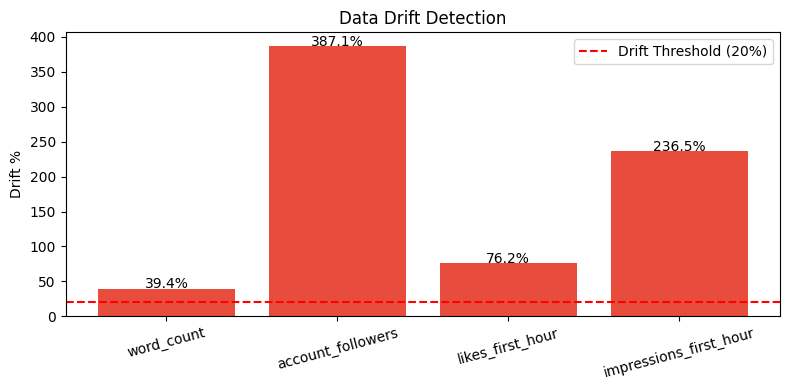

In [ ]:
drift_df = pd.DataFrame(drift_report)

colors = ['#E74C3C' if d > 20 else '#6B8E4E'
          for d in drift_df['Drift %']]

plt.figure(figsize=(8, 4))
bars = plt.bar(drift_df['Column'],
               drift_df['Drift %'],
               color=colors)

for bar, drift in zip(bars, drift_df['Drift %']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{drift:.1f}%',
             ha='center', fontsize=10)

plt.axhline(y=20, color='red',
            linestyle='--', label='Drift Threshold (20%)')
plt.title('Data Drift Detection')
plt.ylabel('Drift %')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Combine original + new data
X_combined = pd.concat([X_train, X_new], ignore_index=True)
y_combined = pd.concat([y_train, y_new], ignore_index=True)

# Train Version 2
model_v2 = RandomForestClassifier(random_state=42)
model_v2.fit(X_combined, y_combined)

v2_accuracy = accuracy_score(y_new, model_v2.predict(X_new))

print('MODEL VERSION 2:')
print(f'Trained on: {len(X_combined)} rows')
print(f'Accuracy on new data: {v2_accuracy:.2%}')
print(f'Timestamp: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

MODEL VERSION 2:
Trained on: 340 rows
Accuracy on new data: 100.00%
Timestamp: 2026-04-04 00:40:05


In [ ]:
with open('model_v2.pkl', 'wb') as f:
    pickle.dump(model_v2, f)

print('✅ Model Version 2 saved!')
print('Filename: model_v2.pkl')

✅ Model Version 2 saved!
Filename: model_v2.pkl


MODEL VERSION COMPARISON:

Version 1 Accuracy : 85.00%
Version 2 Accuracy : 100.00%
Improvement        : 15.00%



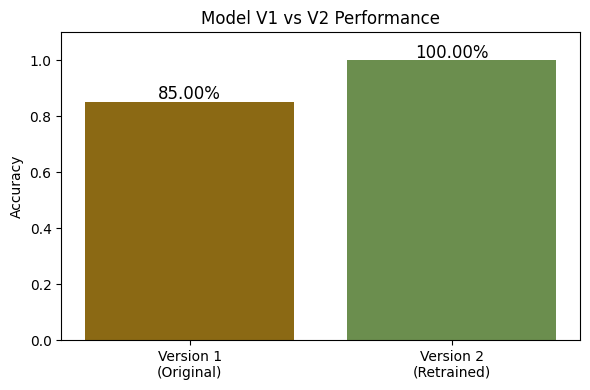

In [ ]:
print('MODEL VERSION COMPARISON:')
print()
print(f'Version 1 Accuracy : {v1_accuracy:.2%}')
print(f'Version 2 Accuracy : {v2_accuracy:.2%}')
print(f'Improvement        : {(v2_accuracy - v1_accuracy):.2%}')
print()

labels = ['Version 1\n(Original)', 'Version 2\n(Retrained)']
scores = [v1_accuracy, v2_accuracy]
colors = ['#8B6914', '#6B8E4E']

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, scores, color=colors)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{score:.2%}',
             ha='center', fontsize=12)

plt.title('Model V1 vs V2 Performance')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [ ]:
print('MLOPS CYCLE SUMMARY:')
print()
print('Step 1 → Model trained and deployed    ✅')
print('Step 2 → New data arrived              ✅')
print('Step 3 → Performance monitored         ✅')
print('Step 4 → Data drift detected           ✅')
print('Step 5 → Model retrained               ✅')
print('Step 6 → New version deployed          ✅')
print()
print('This cycle never stops.')
print('Monitor. Detect. Retrain. Deploy.')
print('Repeat.')

MLOPS CYCLE SUMMARY:

Step 1 → Model trained and deployed    ✅
Step 2 → New data arrived              ✅
Step 3 → Performance monitored         ✅
Step 4 → Data drift detected           ✅
Step 5 → Model retrained               ✅
Step 6 → New version deployed          ✅

This cycle never stops.
Monitor. Detect. Retrain. Deploy.
Repeat.
